In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("C:/Users/abirf/OneDrive/Desktop/Customer Churn Prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.drop('customerID', axis= 'columns', inplace= True)

In [6]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df[pd.to_numeric(df['TotalCharges'], errors= 'coerce').isnull()].shape

(11, 20)

In [8]:
df.shape

(7043, 20)

I am going to drop the null rows as there are only 11 rows where there are null values for TotalCharges column.

In [9]:
df = df[df.TotalCharges!= ' ']

In [10]:
df.shape

(7032, 20)

In [11]:
df.TotalCharges = pd.to_numeric(df.TotalCharges)

In [12]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

### Visualization 

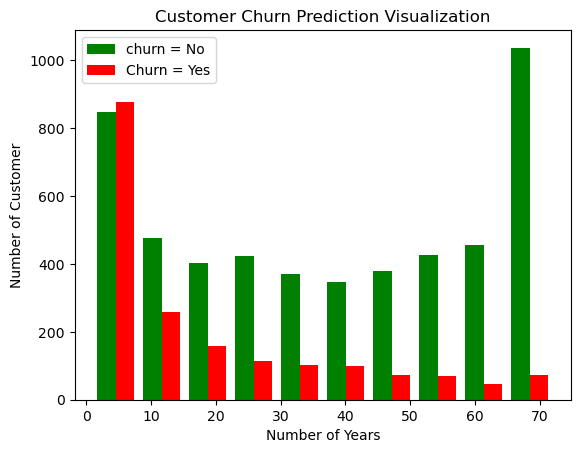

In [13]:
tenure_churn_no = df[df.Churn == "No"].tenure
tenure_churn_yes = df[df.Churn == "Yes"].tenure

plt.xlabel("Number of Years")
plt.ylabel("Number of Customer")
plt.title("Customer Churn Prediction Visualization")

plt.hist([tenure_churn_no, tenure_churn_yes], color=['green', 'red'], label= ['churn = No', 'Churn = Yes'])
plt.legend()

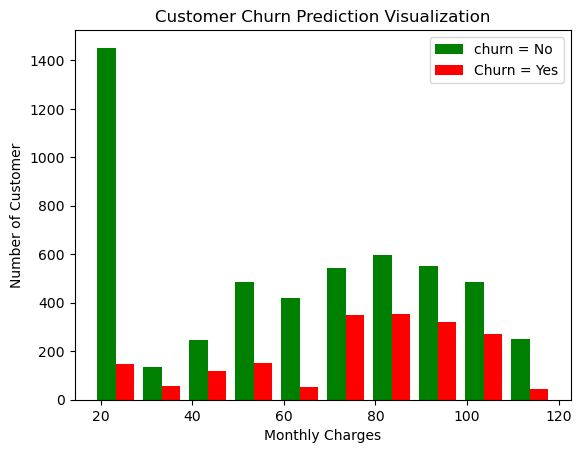

In [14]:
tenure_mc_no = df[df.Churn == "No"].MonthlyCharges
tenure_mc_yes = df[df.Churn == "Yes"].MonthlyCharges

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customer")
plt.title("Customer Churn Prediction Visualization")

plt.hist([tenure_mc_no, tenure_mc_yes], color=['green', 'red'], label= ['churn = No', 'Churn = Yes'])
plt.legend()

In [15]:
for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']:
    print(f"\n{col}:")
    print(df.groupby(col)['Churn'].value_counts(normalize=True).round(3) * 100)


Contract:
Contract        Churn
Month-to-month  No       57.3
                Yes      42.7
One year        No       88.7
                Yes      11.3
Two year        No       97.2
                Yes       2.8
Name: proportion, dtype: float64

InternetService:
InternetService  Churn
DSL              No       81.0
                 Yes      19.0
Fiber optic      No       58.1
                 Yes      41.9
No               No       92.6
                 Yes       7.4
Name: proportion, dtype: float64

PaymentMethod:
PaymentMethod              Churn
Bank transfer (automatic)  No       83.3
                           Yes      16.7
Credit card (automatic)    No       84.7
                           Yes      15.3
Electronic check           No       54.7
                           Yes      45.3
Mailed check               No       80.8
                           Yes      19.2
Name: proportion, dtype: float64

TechSupport:
TechSupport          Churn
No                   No       58.4
        

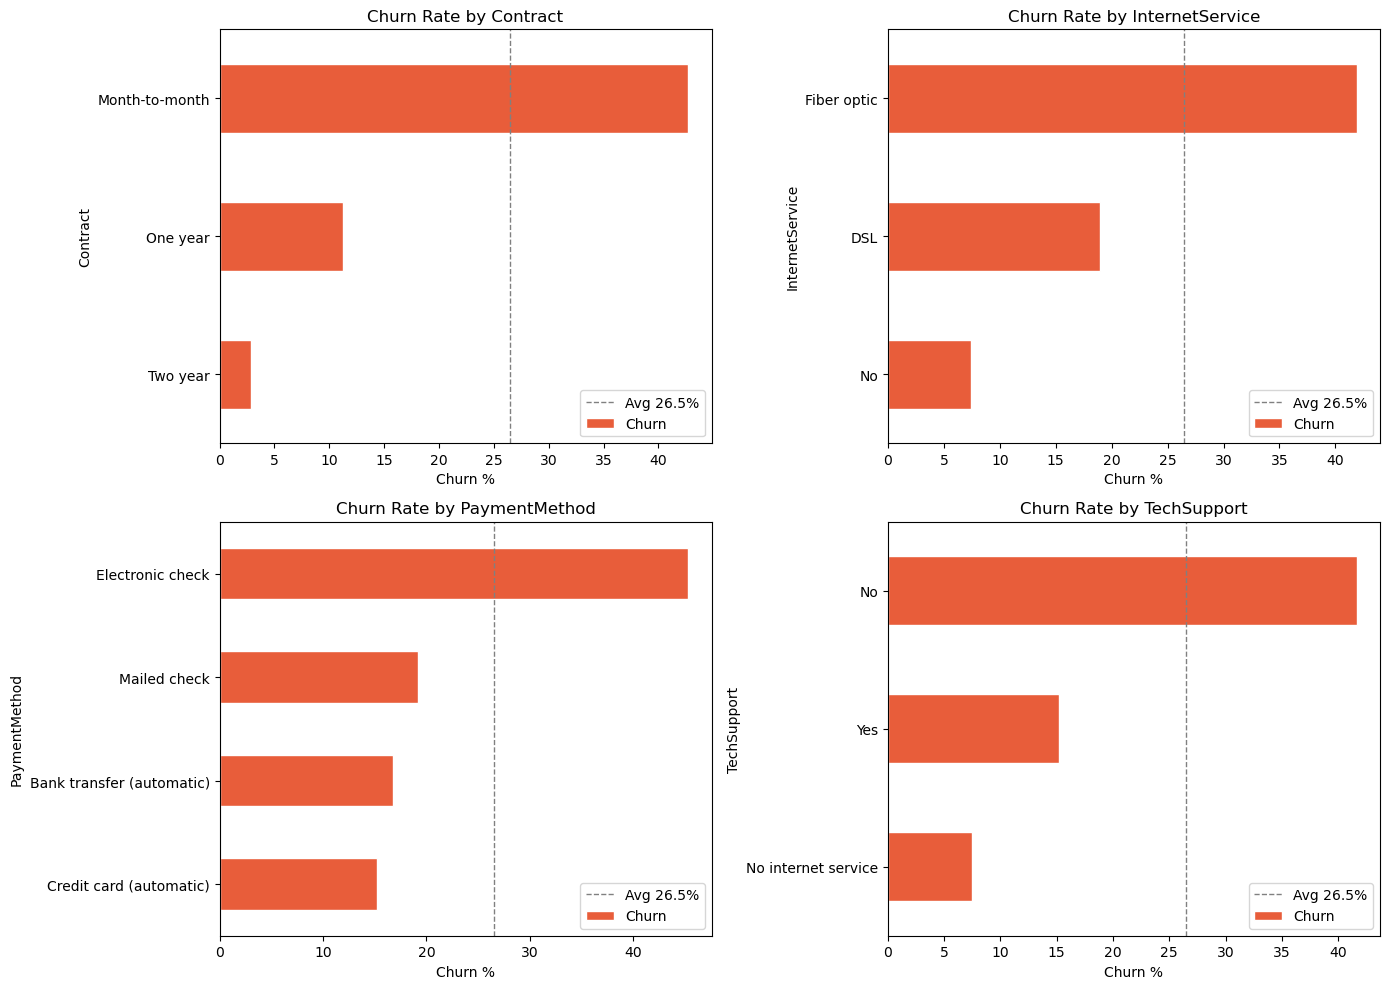

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
for ax, col in zip(axes.flatten(), cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#e85d3a', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn %')
    ax.axvline(26.5, linestyle='--', color='gray', linewidth=1, label='Avg 26.5%')
    ax.legend()

plt.tight_layout()
plt.show()

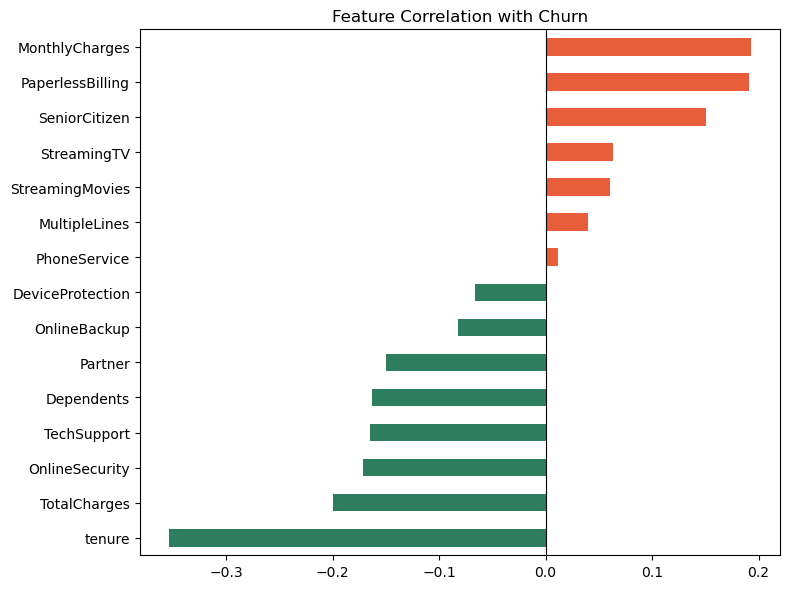

In [17]:
import seaborn as sns

# Quick encode just for correlation view
df_encoded = df.copy()
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

# Encode all Yes/No columns
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup',
               'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# Correlation with Churn only
corr = df_encoded.select_dtypes(include='number').corr()['Churn'].sort_values()

plt.figure(figsize=(8, 6))
corr.drop('Churn').plot(kind='barh', color=corr.drop('Churn').apply(
    lambda x: '#e85d3a' if x > 0 else '#2d7d5f'))
plt.title('Feature Correlation with Churn')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [19]:
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols)

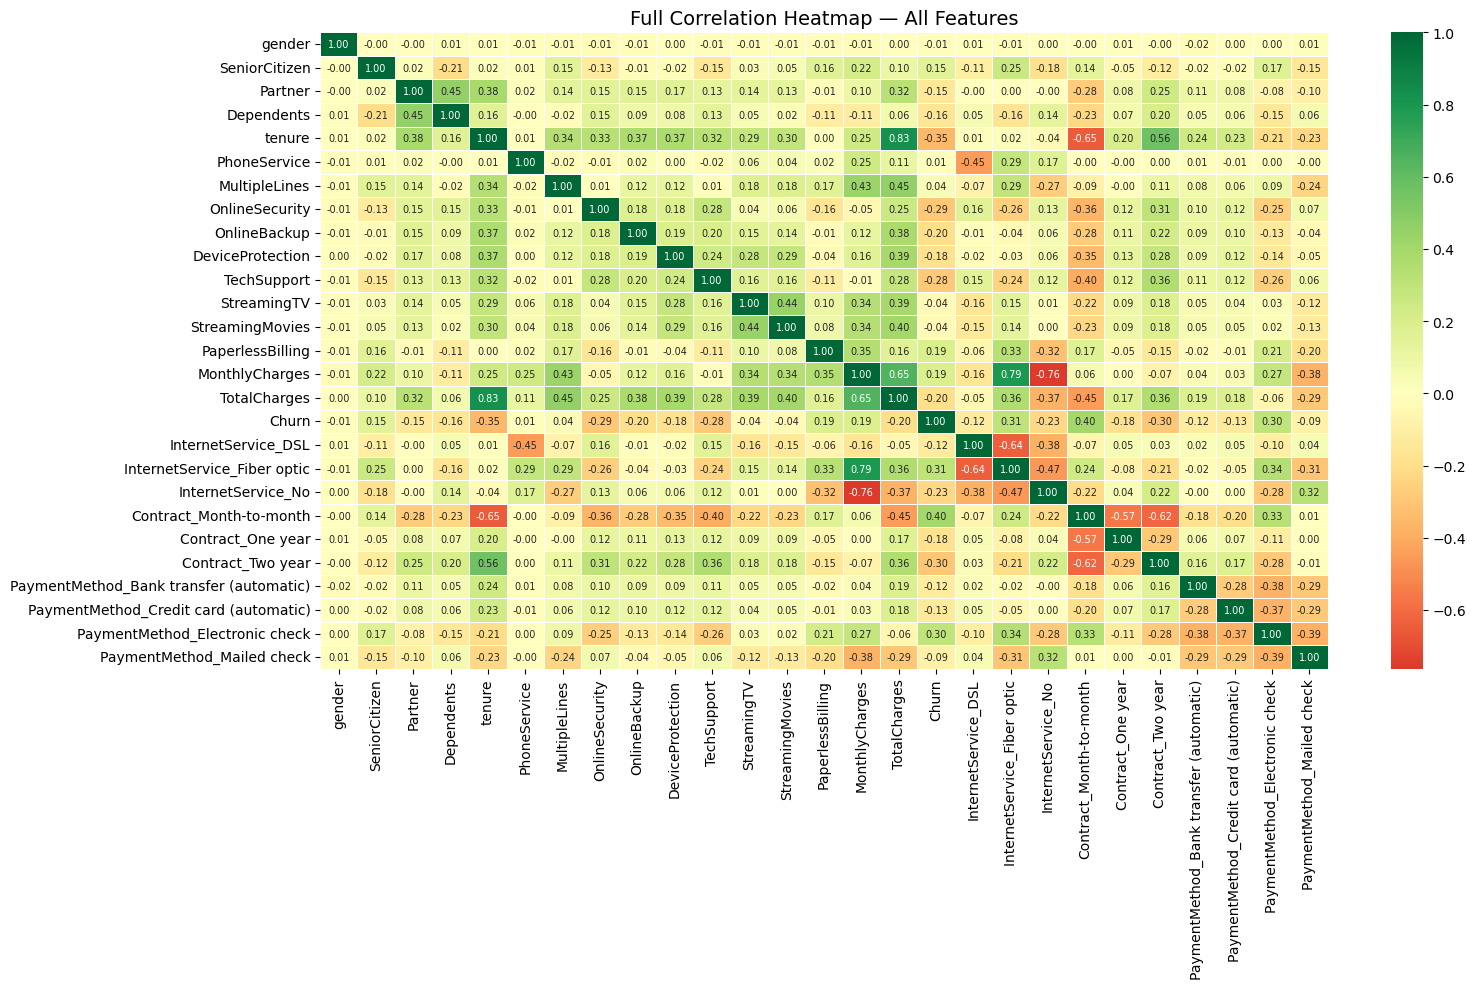

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',   # red = positive, green = negative
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Full Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.show()

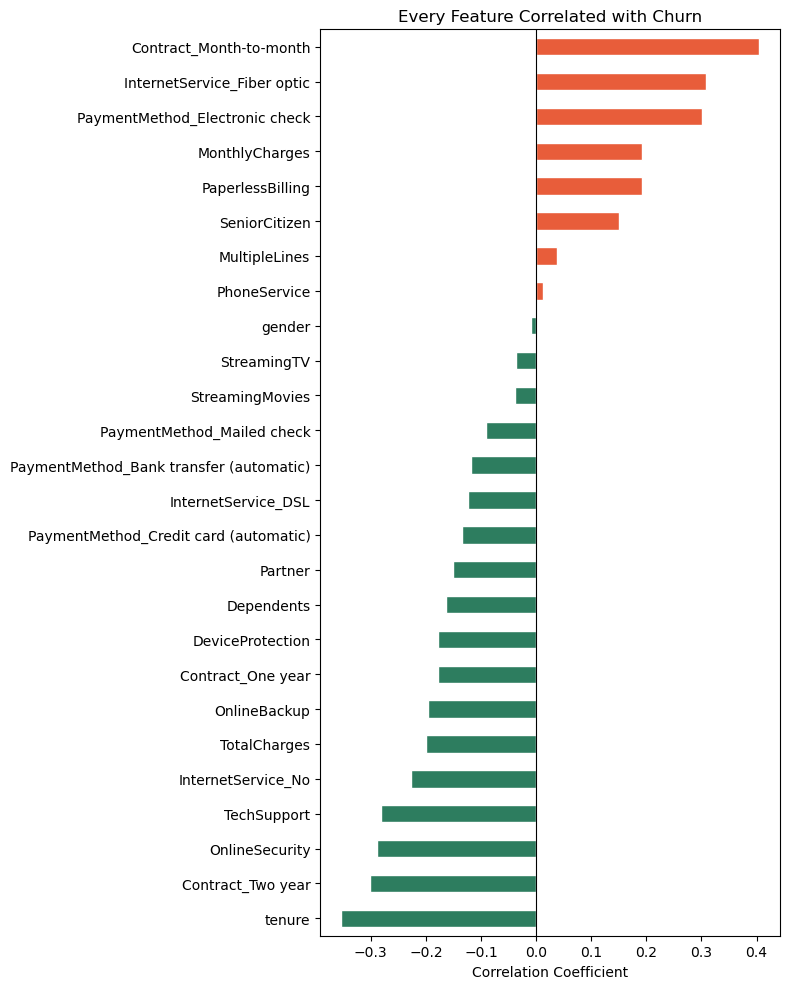

In [21]:
plt.figure(figsize=(8, 10))

churn_corr = df.corr()['Churn'].drop('Churn').sort_values()

colors = ['#e85d3a' if x > 0 else '#2d7d5f' for x in churn_corr]

churn_corr.plot(kind='barh', color=colors, figsize=(8, 10), edgecolor='white')

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Every Feature Correlated with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

|correlation| > 0.15  →  keep it, meaningful signal
|correlation| 0.05–0.15  →  borderline, keep for now
|correlation| < 0.05  →  likely weak, candidate to drop

In [22]:
churn_corr = df.corr()['Churn'].drop('Churn').sort_values()
print(churn_corr)

tenure                                    -0.354049
Contract_Two year                         -0.301552
OnlineSecurity                            -0.289050
TechSupport                               -0.282232
InternetService_No                        -0.227578
TotalCharges                              -0.199484
OnlineBackup                              -0.195290
Contract_One year                         -0.178225
DeviceProtection                          -0.177883
Dependents                                -0.163128
Partner                                   -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
StreamingMovies                           -0.038802
StreamingTV                               -0.036303
gender                                    -0.008545
PhoneService                               0.011691
MultipleLine

In [23]:
# See exact correlations with churn
churn_corr = df.corr()['Churn'].drop('Churn')

# Find weak ones scientifically
weak = churn_corr[abs(churn_corr) < 0.05].index.tolist()
print("Weak features:", weak)

# Drop them
df.drop(columns=weak, inplace=True)
print("Remaining features:", df.shape[1])

Weak features: ['gender', 'PhoneService', 'MultipleLines', 'StreamingTV', 'StreamingMovies']
Remaining features: 22


In [24]:
X = df.drop('Churn', axis=1)  # everything except Churn
y = df['Churn']               # only Churn column

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

X shape: (7032, 21)
y shape: (7032,)
Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # so results are reproducible
    stratify=y            # ← very important for imbalanced data
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5625, 21)
Test set: (1407, 21)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Only scale numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols]) 

In [27]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

X_train shape: (5625, 21)
X_test shape: (1407, 21)

Train churn rate: 0.266
Test churn rate: 0.266


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("═══ Logistic Regression ═══")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

═══ Logistic Regression ═══
Accuracy: 0.7242

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 decision trees
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("═══ Random Forest ═══")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

═══ Random Forest ═══
Accuracy: 0.7832

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=3,     # handles class imbalance (3:1 ratio in your data)
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("═══ XGBoost ═══")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

═══ XGBoost ═══
Accuracy: 0.7427

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



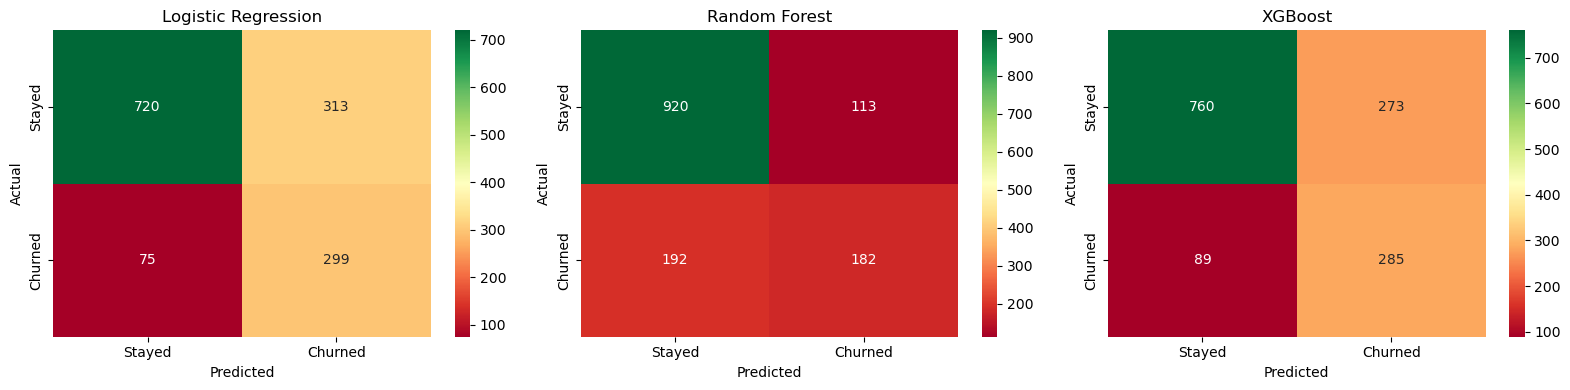

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models = [
    (y_pred_log, 'Logistic Regression'),
    (y_pred_rf,  'Random Forest'),
    (y_pred_xgb, 'XGBoost')
]

for ax, (preds, name) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['Stayed','Churned'],
                yticklabels=['Stayed','Churned'], ax=ax)
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

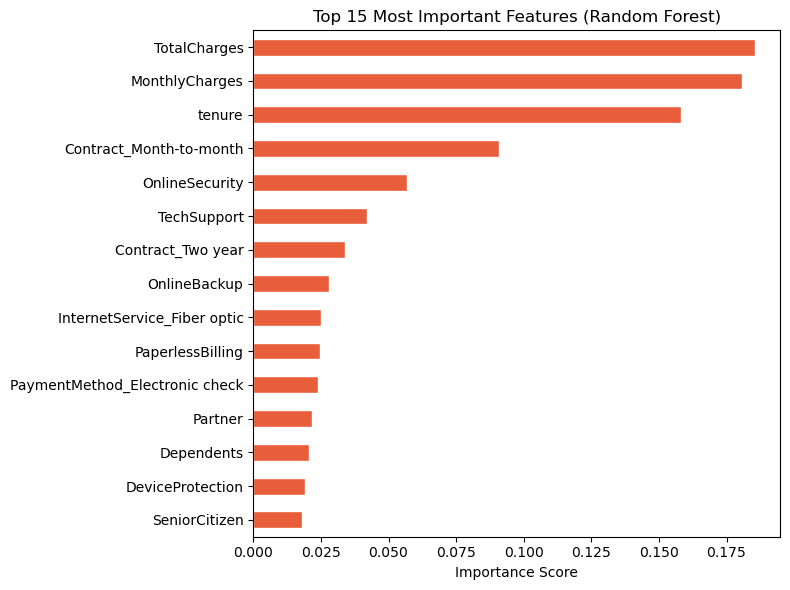

In [32]:
import pandas as pd

feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=True).tail(15).plot(
    kind='barh',
    figsize=(8, 6),
    color='#e85d3a',
    edgecolor='white'
)
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [33]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,               # 5-fold cross validation
    scoring='f1',       # optimize for F1, not accuracy
    n_jobs=-1,          # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_.round(4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 score: 0.6413


In [35]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("═══ Tuned Random Forest ═══")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

═══ Tuned Random Forest ═══
Accuracy:  0.7555

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



In [36]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_grid.best_estimator_.predict(X_test)

print("═══ Tuned XGBoost ═══")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(classification_report(y_test, y_pred_xgb_tuned))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
═══ Tuned XGBoost ═══
Accuracy: 0.7264
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [40]:
import pickle

# Save the model
with open('C:/Users/abirf/OneDrive/Desktop/Customer Churn Prediction/model/churn_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

# Save the scaler too — you'll need it for new predictions
with open('C:/Users/abirf/OneDrive/Desktop/Customer Churn Prediction/model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved successfully!")

Model saved successfully!


In [42]:
import pickle

# Load model
with open('C:/Users/abirf/OneDrive/Desktop/Customer Churn Prediction/model/churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Load scaler
with open('C:/Users/abirf/OneDrive/Desktop/Customer Churn Prediction/model/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("✅ Model and scaler loaded!")
print("\nModel expects these columns:")
print(loaded_model.feature_names_in_.tolist())
print("\nTotal features:", len(loaded_model.feature_names_in_))

✅ Model and scaler loaded!

Model expects these columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Total features: 21


In [43]:
print("Model expects these columns:")
print(loaded_model.feature_names_in_.tolist())
print("\nTotal features:", len(loaded_model.feature_names_in_))

Model expects these columns:
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Total features: 21


In [44]:
model_cols = loaded_model.feature_names_in_.tolist()

# Build new customer with only those columns
new_customer = pd.DataFrame([{col: 0 for col in model_cols}])  # start with all zeros

# Then fill in the values you care about
new_customer['SeniorCitizen'] = 0
new_customer['Partner'] = 0
new_customer['Dependents'] = 0
new_customer['tenure'] = 2
new_customer['OnlineSecurity'] = 0
new_customer['OnlineBackup'] = 0
new_customer['DeviceProtection'] = 0
new_customer['TechSupport'] = 0
new_customer['PaperlessBilling'] = 1
new_customer['MonthlyCharges'] = 85.0
new_customer['TotalCharges'] = 170.0
new_customer['InternetService_Fiber optic'] = 1
new_customer['Contract_Month-to-month'] = 1
new_customer['PaymentMethod_Electronic check'] = 1

# Scale numerical columns
new_customer[num_cols] = scaler.transform(new_customer[num_cols])

# Predict
prediction = loaded_model.predict(new_customer)
probability = loaded_model.predict_proba(new_customer)

print("Prediction:", "WILL CHURN 🔴" if prediction[0] == 1 else "WILL STAY 🟢")
print(f"Churn probability:  {probability[0][1]*100:.1f}%")
print(f"Stay  probability:  {probability[0][0]*100:.1f}%")

Prediction: WILL CHURN 🔴
Churn probability:  89.5%
Stay  probability:  10.5%
